# Parameter estimation from turnover-frequency data

Fit kinetic constants to measured turnover frequencies. The unknowns (here the surface step's pre-exponential `A` and barrier `Ea`) and every condition's coverages are solved simultaneously (all-at-once weighted least squares), and discopt returns the Fisher information, covariance, and confidence intervals. Pre-exponentials are fit in log space and reported in physical units.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline

## Synthetic data: a grid of temperatures and feed compositions

More data, and from varied operating points, makes the fit meaningful. Generate turnover frequencies of CO2 from the *true* mechanism (`A = 1e8`, `Ea = 0.7` on the surface step) across three temperatures and three feed compositions, then add 3% measurement noise.

In [2]:
import numpy as np
import discopt.mkm as mk
from discopt.mkm.examples import co_oxidation

TEMPS = [470.0, 500.0, 530.0]
FEEDS = [(1.0, 0.5), (2.0, 0.5), (0.5, 1.0)]      # (P_CO, P_O2)
conds = [(T, pco, po2) for T in TEMPS for pco, po2 in FEEDS]

def true_tof(T, pco, po2):
    m, _ = co_oxidation(T=T)
    CO, O2, CO2 = (m._by_name[n] for n in ('CO', 'O2', 'CO2'))
    sol = mk.solve_steady_state(m, mk.DifferentialReactor({CO: pco, O2: po2, CO2: 0.0}))
    return sol.production_rate(CO2)

clean = np.array([true_tof(T, a, b) for T, a, b in conds])
noise = 0.03
rng = np.random.default_rng(0)
data = clean * (1 + rng.normal(0, noise, clean.shape))
print(f'{len(conds)} measurements over {len(TEMPS)} temperatures x {len(FEEDS)} feeds')
print('TOF range:', f'{clean.min():.2f} - {clean.max():.2f}')

9 measurements over 3 temperatures x 3 feeds
TOF range: 0.22 - 2.51


## Fit `A` and `Ea` with confidence intervals

Each `Observation` carries its own temperature and partial pressures, so one `fit_kinetics` call handles the whole grid.

In [3]:
m, _ = co_oxidation(T=500.0)
CO, O2, CO2 = (m._by_name[n] for n in ('CO', 'O2', 'CO2'))
surf = m.reactions[2]
obs = [mk.Observation(response=CO2, value=v, T=T, pressures={CO: a, O2: b, CO2: 0.0},
                      sigma=max(noise*v, 1e-3))
       for (T, a, b), v in zip(conds, data)]
fit = [mk.FitParam(surf, 'A',  lb=1e6, ub=1e10, init=3e7),
       mk.FitParam(surf, 'Ea', lb=0.3, ub=1.2, init=0.5)]
result = mk.fit_kinetics(m, obs, fit)
print(result)
print('\ntrue: A = 1e8, Ea = 0.7')

MKMEstimationResult:
  A_surface_reaction = 1.07012e+08  (95% CI [6.593e+07, 1.737e+08])
  Ea_surface_reaction = 0.702639  (95% CI [0.6818, 0.7234])
  objective=3.31385, n_obs=9

true: A = 1e8, Ea = 0.7


## Plot the fit and its statistics

Left: a parity plot of the fitted-model turnover frequency against every measurement (color = temperature); points on the dashed line are a good fit. Right: each estimated constant relative to its true value with the 95% confidence interval.

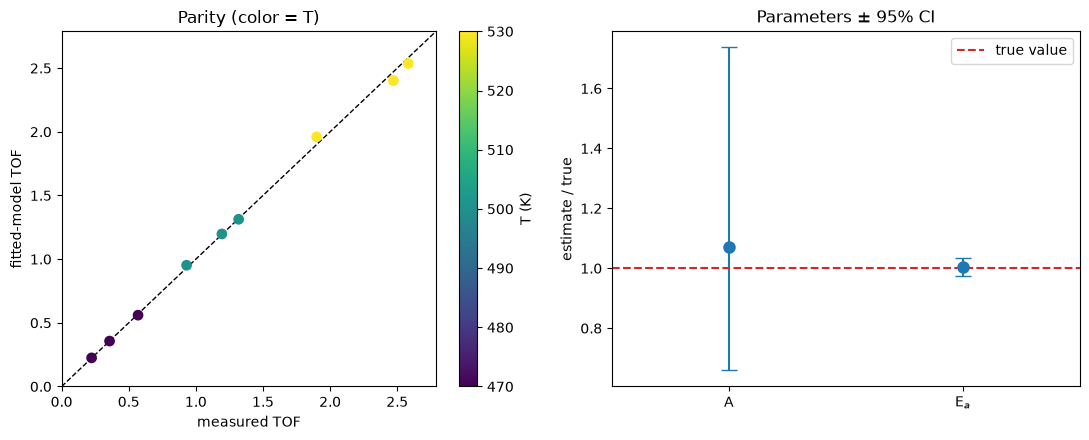

In [4]:
import matplotlib.pyplot as plt
kA, kE = fit[0].resolved_name(), fit[1].resolved_name()
A_fit, Ea_fit = result.parameters[kA], result.parameters[kE]

pred = []
for T, a, b in conds:
    mm, _ = co_oxidation(T=T)
    mm.reactions[2].A, mm.reactions[2].Ea = A_fit, Ea_fit
    c2 = mm._by_name['CO2']; cO, o2 = mm._by_name['CO'], mm._by_name['O2']
    pred.append(mk.solve_steady_state(mm, mk.DifferentialReactor({cO: a, o2: b, c2: 0.0})).production_rate(c2))
pred = np.array(pred)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax[0].scatter(data, pred, c=[c[0] for c in conds], cmap='viridis', s=45, zorder=3)
lim = [0, max(data.max(), pred.max())*1.08]
ax[0].plot(lim, lim, 'k--', lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel('measured TOF'); ax[0].set_ylabel('fitted-model TOF')
ax[0].set_title('Parity (color = T)'); fig.colorbar(sc, ax=ax[0], label='T (K)')

labels, truths, fitv = ['A', 'E$_a$'], [1e8, 0.7], [A_fit, Ea_fit]
ci = [result.confidence_intervals[kA], result.confidence_intervals[kE]]
x = np.arange(2)
lo = [(fitv[i] - ci[i][0]) / truths[i] for i in range(2)]
hi = [(ci[i][1] - fitv[i]) / truths[i] for i in range(2)]
ax[1].errorbar(x, [fitv[i]/truths[i] for i in range(2)], yerr=[lo, hi], fmt='o', ms=8, capsize=6, color='C0')
ax[1].axhline(1.0, color='C3', ls='--', label='true value')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels); ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylabel('estimate / true'); ax[1].legend(); ax[1].set_title('Parameters $\\pm$ 95% CI')
fig.tight_layout()